# Imports

In [12]:
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.coordinates import FK5
from astropy.time import Time, TimeDelta
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
import healpy as hp
import matplotlib.pyplot as plt
from astropy.coordinates import Angle
from astropy import units
from scipy.interpolate import RectBivariateSpline
from scipy import interpolate
import copy
import os
import sys
from tqdm.notebook import tqdm
from tqdm import tqdm
import glob
import h5py
import matplotlib
# from src2.ms_fit_joint import *
from src2.fit_funcs import *
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams["font.size"] = "18"
PATH="../Sensitivty_files/Sky_spectrum/"
import scipy.io

## Load necessary files and store constants

In [5]:
sellon=-140.625
sellat=-18.209956864283015
power_output=np.load('../Sensitivty_files/power_output.npy',allow_pickle=True)

In [9]:
CHANNEL_WIDTH       = 0.06103515625/2.0 #/* MHz */
NUMBER_OF_CHANNELS  = 8193
START_FREQUENCY     = 0.00 #/* MHz */

PCHANNEL_WIDTH      = 16.0*0.06103515625 #/* MHz */
PNUMBER_OF_CHANNELS = 41
PSTART_FREQUENCY    = 210.44921875 #/* MHz */

RCHANNEL_WIDTH      = 16.0*0.06103515625 #/* MHz */
RNUMBER_OF_CHANNELS = 103
RSTART_FREQUENCY    = 109.86328125 #/* MHz */

QCHANNEL_WIDTH      = 16.0*0.06103515625 #/* MHz */
QNUMBER_OF_CHANNELS = 72
QSTART_FREQUENCY    = 39.5507812500 #/* MHz */

SITE_LATITUDE       = sellat
SITE_LONGITUDE      = sellon
NHPIX               = 3072
PI                  = 3.14159265358979

TCMB                = 2.72548

filename_coord      = "PIXEL_LISTING_NESTED_R4_GALACTIC.txt" #GMOSS

filename_pix_spec1  ="total_model_spec_13jan17_3072pix_103fq.txt"
filename_pix_spec2  ="total_model_spec_24jan17_1_3072_freq_40_110_MHz_16spacing.txt"
filename_pix_spec3  ="total_model_spec_31jan17_210_250_16spacing.txt"

beam_path  = '/Users/EoR/Desktop/PRATUSH/PRATUSH/elec_small_ant_with_2_12U_bus_cone_scale_0_925_ref_scale_0_9999/'
rt_file    = 'gamma_linear.txt'
file_list  = sorted(glob.glob(os.path.join(beam_path,"*mhz.txt")))


##### Fitting constants

fmin = 56.0/1e3
fmax = 109.0/1e3

LOWF   = fmin*1e3
HGHF   = fmax*1e3


In [10]:
def Read_Two_Column_File(file_name):
    with open(file_name, 'r') as data:
        x = []
        y = []
        for val, line in enumerate(data):
            if val==0:
                continue
            p = line.split()
            x.append(float(p[0]))
            y.append(float(p[1]))
    return x, y

def Read_pixel_freq(file_name, nfreq):
    with open(file_name, 'r') as data:
        x = np.zeros((NHPIX, nfreq))
        for val, line in enumerate(data):
            if val==0:
                continue
            x[val-1] = [float(i) for i in line.split()]
    return x, np.shape(x)[1]

def select_freq_1d(x1, low, high): 
    prl = 0 
    prh = 0 
    for i in range(0, len(x1)):
        if x1[i]<=low:
            i_low=i+1
            prl = 1 
        if x1[i]>=high:
            i_high=i
            prh = 1 
            break
    if prl==1 and prh==0:
        i_high = len(x1)-1
    if prl==0 and prh==1:
        i_low = 1    
    return i_low, i_high


Processing frequency 55.0 MHz
Processing frequency 57.5 MHz
Processing frequency 60.0 MHz
Processing frequency 62.5 MHz
Processing frequency 65.0 MHz
Processing frequency 67.5 MHz
Processing frequency 70.0 MHz
Processing frequency 72.5 MHz
Processing frequency 75.0 MHz
Processing frequency 77.5 MHz
Processing frequency 80.0 MHz
Processing frequency 82.5 MHz
Processing frequency 85.0 MHz
Processing frequency 87.5 MHz
Processing frequency 90.0 MHz
Processing frequency 92.5 MHz
Processing frequency 95.0 MHz
Processing frequency 97.5 MHz
Processing frequency 100.0 MHz
Processing frequency 102.5 MHz
Processing frequency 105.0 MHz
Processing frequency 107.5 MHz
Processing frequency 110.0 MHz


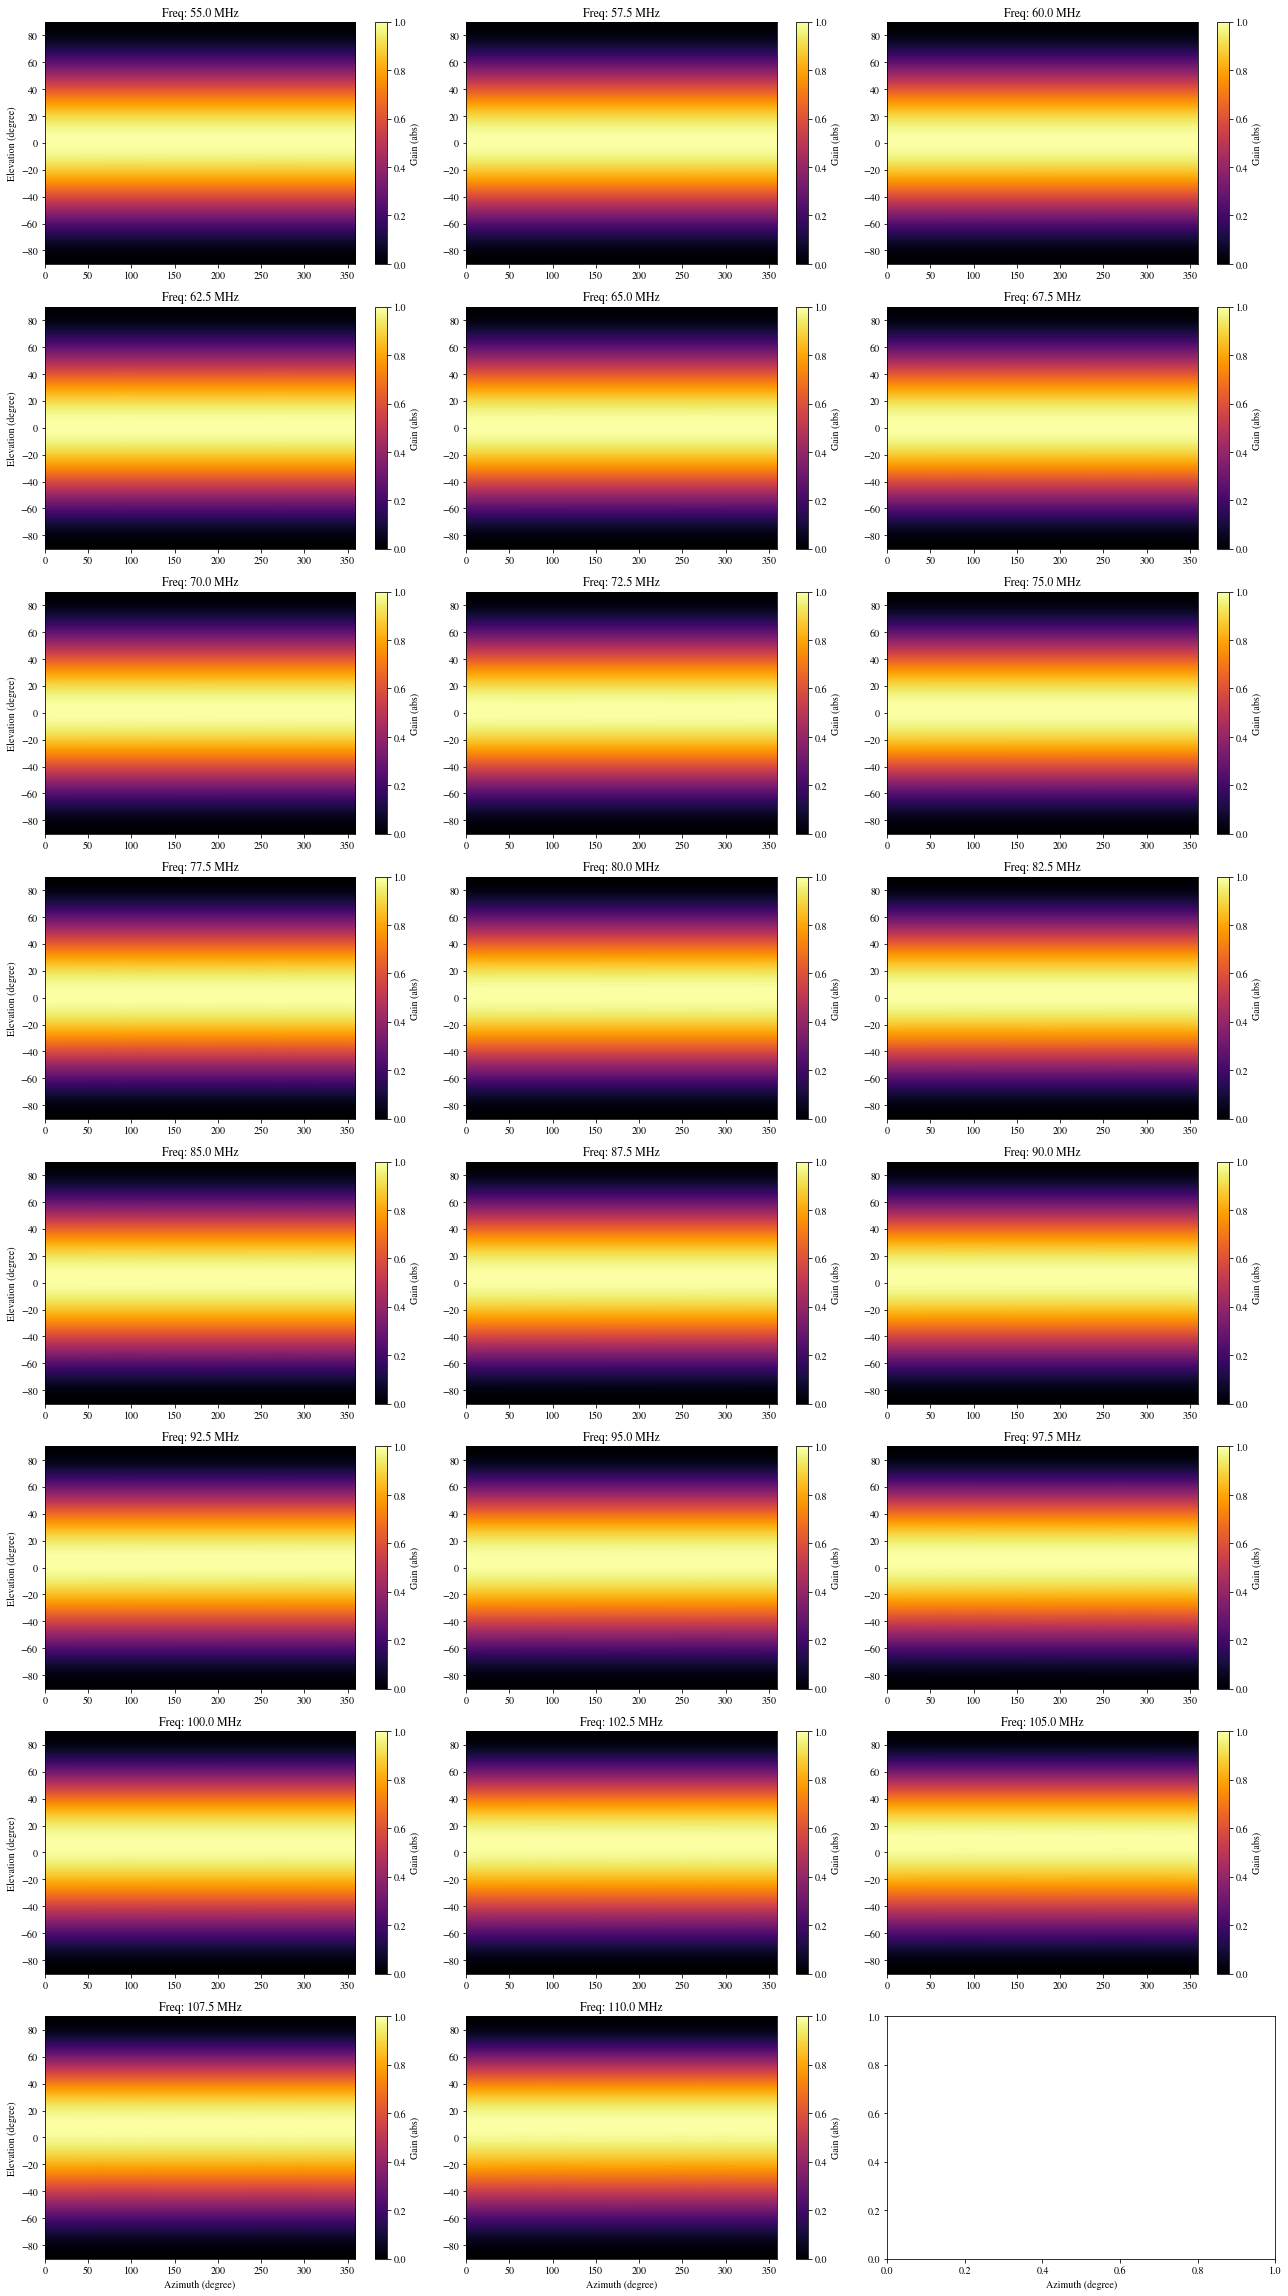

In [11]:
gamme_file = os.path.join(beam_path, rt_file)

gamma_freq = []
gamma_val  = []

with open(gamme_file) as fa:
    for line_aa in fa.readlines()[3:]:
        line_aa = line_aa.strip()
        col1    = line_aa.split('\t')
        _freq   = np.array(list(map(float, col1[0].split())))[0]
        _val    = np.array(list(map(float, col1[1].split())))[0]
        gamma_freq.append(_freq)
        gamma_val.append(_val)
        
gamma_freq = np.array(gamma_freq)
gamma_val  = np.array(gamma_val)
    
gamma_func = scipy.interpolate.interp1d(gamma_freq, gamma_val)
phi_res   = 1
theta_res = 1

phi_array   = np.arange(0, 360, phi_res)
theta_array = np.arange(-90, 90 + theta_res, theta_res) #because arange does not accept endpoint. Stupid.
freq_array  = []
file_array  = []

def get_freq_from_file(filename):
    _temp = os.path.basename(filename).replace('.txt','').replace('mhz','')
    return float(_temp)
    
for ii, file_add in enumerate(file_list):
    freq_array.append(get_freq_from_file(file_add))
    file_array.append(file_add)
    
np.testing.assert_array_equal(file_array, file_list)

freq_array = np.array(freq_array)
file_array = np.array(file_array)

isort      = np.argsort(freq_array)
freq_array = freq_array[isort]
file_array = file_array[isort]

beam_3D_unnorm = np.zeros((len(freq_array), len(theta_array), len(phi_array)))

for ii, freq in enumerate(freq_array):
    print("Processing frequency {:.1f} MHz".format(freq))
    file_add = file_array[ii]
    with open(file_add) as fa:
        for line_aa in fa.readlines()[2:]:
            line_aa = line_aa.strip()
            col1    = line_aa.split('\t')
            all_val = np.array(list(map(float, col1[0].split())))

            theta   = all_val[0] - 90
            phi     = all_val[1]
            beam    = all_val[2]
            
            iphi    = np.where(phi_array==phi)[0][0]
            itheta  = np.where(theta_array==theta)[0][0]
            beam_3D_unnorm[ii, itheta, iphi] = beam

beam_3D = np.zeros((len(freq_array), len(theta_array), len(phi_array)))
for ifreq in range(beam_3D.shape[0]):
    for iphi in range(beam_3D.shape[2]):
        beam_3D[ifreq,:,iphi] = beam_3D_unnorm[ifreq, :, iphi]/np.amax(beam_3D_unnorm[ifreq, :, iphi])

theta_array_new = theta_array
phi_array_new   = phi_array

from scipy.interpolate import RegularGridInterpolator
my_interpolating_function = RegularGridInterpolator((\
                                                     freq_array, theta_array_new, \
                                                     phi_array_new), beam_3D)

extent = (phi_array[0], phi_array[-1], theta_array[0], theta_array[-1])

nplots = len(freq_array)
ncol   = 3
nrow   = int(np.ceil(nplots/ncol))

fig, _ax = plt.subplots(nrow,ncol,figsize=(6*ncol,4*nrow))
axs      = np.ravel(_ax)

for val, (ax, freq) in enumerate(zip(axs, freq_array)):
    im = ax.imshow(beam_3D[val], aspect='auto', origin='lower', \
                   extent=extent, vmin=0, vmax=1, cmap='inferno')
    fig.colorbar(im, ax=ax, label='Gain (abs)')
    ax.set_title("Freq: {:.1f} MHz".format(freq))

for ax in _ax[:,0]:
    ax.set_ylabel("Elevation (degree)")
for ax in _ax[-1]:
    ax.set_xlabel("Azimuth (degree)")
    
fig.tight_layout()
# plt.savefig("beam_plot", dpi=100)
plt.show()

nfreq, ntheta, nphi = beam_3D.shape
ind_phi_0 = np.argmin(np.abs(phi_array))



## GMOSS

In [13]:
ll_coordinate, bb_coordinate = np.radians(Read_Two_Column_File(PATH+filename_coord))

T1, nspec1 = Read_pixel_freq(PATH+filename_pix_spec1, RNUMBER_OF_CHANNELS)
T2, nspec2 = Read_pixel_freq(PATH+filename_pix_spec2, QNUMBER_OF_CHANNELS)
T3, nspec3 = Read_pixel_freq(PATH+filename_pix_spec3, PNUMBER_OF_CHANNELS)

freq    = np.zeros(nspec1+nspec2+nspec3)
T_pix   = np.zeros((NHPIX, nspec1+nspec2+nspec3))
print(np.shape(T_pix))

for i in range(0, nspec2):
    freq[i]=(float)(QSTART_FREQUENCY/1000.0) +\
            ((float)(QCHANNEL_WIDTH)/1000.0)*(float)(i)
for i in range(nspec2, (nspec1+nspec2)):
    freq[i]=(float)(RSTART_FREQUENCY/1000.0) + ((float)(RCHANNEL_WIDTH)/1000.0)*(float)(i-nspec2)
for i in range(nspec1+nspec2, (nspec1+nspec2+nspec3)):
    freq[i]=(float)(PSTART_FREQUENCY/1000.0)+((float)(PCHANNEL_WIDTH)/1000.0)*(float)(i-(nspec1+nspec2))

for j in range(0, NHPIX):
    T_pix[j][0:nspec2]=T2[j]
    T_pix[j][(nspec2):(nspec1+nspec2)]=T1[j]
    T_pix[j][(nspec1+nspec2):(nspec1+nspec2+nspec3)]=T3[j]
    
freq_org, T_pix_org = copy.deepcopy(freq), copy.deepcopy(T_pix)


(3072, 216)


In [14]:
ifr_low, ifr_hgh = select_freq_1d(freq_org, fmin, fmax)
freq  = freq_org[ifr_low:ifr_hgh]*1e3
T_pix = T_pix_org[:,ifr_low:ifr_hgh]

In [16]:
data21   = scipy.io.loadmat('/Users/EoR/Desktop/PRATUSH/STARFIRE_2_backup/Sensitivty_files/Sky_spectrum/Data_18March_wMFP.mat')
data21   = data21['Data2']/1e3 
fr       = np.loadtxt('/Users/EoR/Desktop/PRATUSH/STARFIRE_2_backup/Sensitivty_files/Sky_spectrum/freq_saras.txt') #Frequency in MHz
signal   = interpolate.interp1d(fr, data21)

# Convolve sky + RFI with beam pattern

In [18]:
NPIX = hp.nside2npix(16) # Storing the number of pixels of the map corresponding to the given NSIDE
pix=hp.ang2pix(16,sellon,sellat,lonlat=True)

NPIX = 3072 # Storing the number of pixels of the map corresponding to the given NSIDE
pix=hp.ang2pix(16,sellon,sellat,lonlat=True)

Processing time: 2019-04-12 23:00:00.000
Processing time: 2019-04-13 05:00:00.000
Processing time: 2019-04-13 11:00:00.000
Processing time: 2019-04-13 17:00:00.000
Processing time: 2019-04-13 23:00:00.000


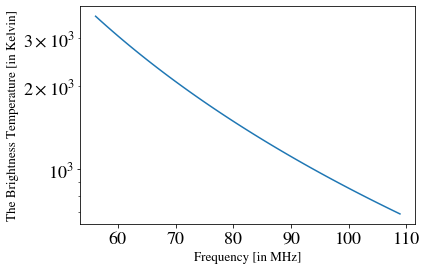

In [20]:
dt = TimeDelta(np.linspace(0.,24.*3600, 5), format='sec') #Will take ~5 min

obstimes = Time('2019-4-12 23:00:00') + dt

hanle = EarthLocation(lat=SITE_LATITUDE*u.deg, lon=SITE_LONGITUDE*u.deg, height=4500*u.m)
gc    = SkyCoord(l=ll_coordinate*u.radian, b=bb_coordinate*u.radian,\
        frame='galactic')

#Get RA, DEC 
trans      = gc.transform_to('icrs')
ra, dec    = trans.ra.hour, trans.dec.hour

observing_time = Time(obstimes, scale='utc', location=hanle)
LST            = observing_time.sidereal_time('mean').value

T_monopole_AUS_sin = np.zeros((obstimes.shape[0], freq.shape[0]))

nside=16
NPIX = hp.nside2npix(nside) # Storing the number of pixels of the map corresponding to the given NSIDE
arr=np.arange(NPIX)
# elev_ang=np.load('/home/saurabhs/Documents/Yogen_starfire/skymodels/elev_angle.npy',allow_pickle=True)
freq_rfi=np.arange(55,110,1)
freq1=freq_rfi
pix=hp.ang2pix(nside,sellon,sellat,lonlat=True)

for val, (time,i) in enumerate(zip(obstimes, tqdm(range(len(obstimes))))):
    
    print("Processing time: {}".format(time))
   
    #Get Alt, Az
    
    trans_local                 = gc.transform_to(AltAz(obstime=time, location=hanle))
    az, alt                     = trans_local.az.degree, trans_local.alt.degree
   
    ind_below_horizon           = alt < 0
       
    ############################
    
    beam_gen = np.zeros_like(T_pix)

    for ifreq, freq_value in enumerate(freq):
        rogue_phi  = []
        for iangle, (alt_value, az_value) in enumerate(zip(alt, az)):
            
            if az_value > phi_array_new.max():
                rogue_phi.append(az_value)
                az_value = 360 - az_value
                
            beam_gen[iangle,ifreq] = my_interpolating_function([freq_value, alt_value, az_value])
    beam_gen[ind_below_horizon,:] = np.nan   
                                        
    T_monopole_AUS_sin[val]                      = (np.nansum(T_pix * beam_gen + power_output[0,pix,:],axis=0)/np.nansum(beam_gen,axis=0))
                                                                                    
    #############################


plt.plot(freq,T_monopole_AUS_sin[0])
plt.xlabel('Frequency [in MHz]',fontsize=13)
plt.ylabel('The Brightness Temperature [in Kelvin]',fontsize=13)
plt.yscale('log')



In [ ]:
power_output[1,pix,:]

## Add system noise

In [21]:
tau=158.69*3600
sigma=np.zeros((5,55))
for i in range(5):
    for j in range(55):
        sigma[i,j]=(70+T_monopole_AUS_sin[i,j])/(np.sqrt((1e6)*tau))
        T_monopole_AUS_sin[i,j]+=np.random.normal(0,1,1)*sigma[i,j]

## Residuals for null hypothesis

In [22]:
freq_null=copy.deepcopy(freq)

In [42]:
avg_spectra = np.mean(T_monopole_AUS_sin, axis=0) 
# Add radiometer noise

flags=avg_spectra>1e4
avg_spectra=avg_spectra[~flags]
freq_null=freq_null[~flags]
freq_null = np.asarray(freq_null, dtype=np.float64)
avg_spectra = np.asarray(avg_spectra, dtype=np.float64)
e=np.ones_like(freq_null)

# Codes taken from investigation_cleaner.ipynb

for i in range(3,11):
    print(i)
    initial_ = np.zeros(i, dtype='float128')
    if i ==3:
        initial_ = np.polyfit(y= np.log10(avg_spectra), x = rescale(freq_null), deg = 2)
    if i > 3:
        if para_new[0] ==0:
            p_order = len(para_new)-2
            break
        initial_[1:] = np.array(para_new, dtype='float128')
    para_new,res_cons,fit_curve_mag, chi_mag = chi_dunk(x1=freq_null,y1=avg_spectra,\
                                             p00=initial_, gloss = True, keju_inf=0,\
                                               e1=e,iterations=50)
    

3
initial_6



Coefficients : [-1.03556472e-03 -3.54440950e-01  3.28021059e+00] 

Residual rms : 0.26757318988959083
4
initial_6



Coefficients : [ 3.09356534e-04 -9.28069602e-04 -3.54614941e-01  3.28017670e+00] 

Residual rms : 0.06673059025177887
5
initial_6



Coefficients : [-8.71169768e-05  3.48467907e-04 -8.24874608e-04 -3.54633510e-01
  3.28016092e+00] 

Residual rms : 0.023749820354761916
6
initial_6



Coefficients : [ 9.41995513e-08 -8.71174903e-05  3.47527966e-04 -8.25175830e-04
 -3.54633023e-01  3.28016102e+00] 

Residual rms : 0.023742852640411614
7
initial_6



Coefficients : [ 1.57829129e-08  9.46974823e-08 -8.71176856e-05  3.47208109e-04
 -8.25300043e-04 -3.54632844e-01  3.28016105e+00] 

Residual rms : 0.023741721550501426
8
initial_6



Coefficients : [ 2.56135701e-09  1.79294991e-08  5.37887935e-08 -8.71176572e-05
  3.47484503e-04 -8.25223976e-04 -3.54632985e-01  3.28016103e+00] 

Residual rms : 0.023739799966942705
9
initial_6



Coefficients : [ 0.00000000e+00  2.56135701e-09  1.79294998e-08  5.37887935e-08
 -8.71176572e-05  3.47484503e-04 -8.25223978e-04 -3.54632985e-01
  3.28016103e+00] 

Residual rms : 0.023739799965318664
10


In [46]:
rms_null = np.sqrt(np.mean(res_cons**2))
print(rms_null)

0.023739799965318664


## Inject 21 cm signal

In [47]:
data21   = scipy.io.loadmat('/Users/EoR/Desktop/PRATUSH/STARFIRE_2_backup/Sensitivty_files/Sky_spectrum/Data_18March_wMFP.mat')
data21   = data21['Data2']/1e3 
fr       = np.loadtxt('/Users/EoR/Desktop/PRATUSH/STARFIRE_2_backup/Sensitivty_files/Sky_spectrum/freq_saras.txt') #Frequency in MHz
signal   = interpolate.interp1d(fr, data21)
T21=  signal(freq)[100]*1 #max 263 
freq_alt=copy.deepcopy(freq)

In [48]:
avg_spectra1 = np.mean(T_monopole_AUS_sin, axis=0)+T21

flags=avg_spectra1>1e4

avg_spectra1=avg_spectra1[~flags]
freq_alt=freq_alt[~flags]
freq_alt = np.asarray(freq_alt, dtype=np.float64)
avg_spectra1 = np.asarray(avg_spectra1, dtype=np.float64)
e=np.ones_like(freq_alt)

# Codes taken from investigation_cleaner.ipynb

for i in range(3,11):
    print(i)
    initial_ = np.zeros(i, dtype='float128')
    if i ==3:
        initial_ = np.polyfit(y= np.log10(avg_spectra1), x = rescale(freq_alt), deg = 2)
    if i > 3:
        if para_new1[0] ==0:
            p_order = len(para_new1)-2
            break
        initial_[1:] = np.array(para_new1, dtype='float128')
    para_new1,res_cons1,fit_curve_mag1, chi_mag1 = chi_dunk(x1=freq_alt,y1=avg_spectra1,\
                                             p00=initial_, gloss = True, keju_inf=0,\
                                               e1=e,iterations=50)
    #fit_curves_array = np.vstack((fit_curves_array,fit_curve_))
    #print(np.std(res_ns))

3
initial_6



Coefficients : [-1.00243727e-03 -3.54447557e-01  3.28017913e+00] 

Residual rms : 0.29787796761894897
4
initial_6



Coefficients : [ 3.00668582e-04 -9.02005746e-04 -3.54618192e-01  3.28014727e+00] 

Residual rms : 0.10301790862975181
5
initial_6



Coefficients : [-9.66796615e-05  3.86718646e-04 -7.68618686e-04 -3.54661259e-01
  3.28012401e+00] 

Residual rms : 0.03542199086239699
6
initial_6



Coefficients : [ 2.65302802e-07 -9.66817840e-05  3.84074108e-04 -7.69462753e-04
 -3.54659889e-01  3.28012427e+00] 

Residual rms : 0.035384508973224864
7
initial_6



Coefficients : [-2.58228193e-11  2.72955070e-07 -9.66844961e-05  3.84008950e-04
 -7.69469890e-04 -3.54659845e-01  3.28012428e+00] 

Residual rms : 0.03538415565225433
8
initial_6



Coefficients : [-1.62532445e-14 -2.85846136e-11  1.29622820e-05 -1.22324269e-04
  3.59674828e-04 -7.48313367e-04 -3.54650864e-01  3.28012245e+00] 

Residual rms : 0.033497120982347674
9
initial_6



Coefficients : [ 0.00000000e+00 -1.63548024e-14 -2.85846552e-11  1.29622820e-05
 -1.22324269e-04  3.59674828e-04 -7.48313421e-04 -3.54650864e-01
  3.28012245e+00] 

Residual rms : 0.0334971209817827
10


In [52]:
excess_rms = np.sqrt(np.std(avg_spectra1-fit_curve_mag1)**2-np.std(avg_spectra-fit_curve_mag)**2)
print(excess_rms/np.std(avg_spectra-fit_curve_mag))

0.9954660351839554


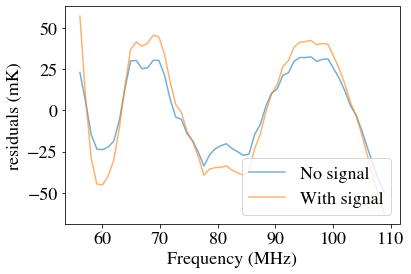

In [50]:
plt.plot(freq_null, (avg_spectra-fit_curve_mag)*1000, alpha=0.6,label="No signal")
plt.plot(freq_null, (avg_spectra1-fit_curve_mag1)*1000, alpha=0.6,label="With signal")
# plt.plot(freq,T21*1000)
plt.legend()
plt.ylabel('residuals (mK)')
plt.xlabel('Frequency (MHz)')
plt.show()

## Run for each model

In [ ]:
check_smoothness(para_new,freq_null,keju_inf=1)